# Human Activity Recognition con 1D CNN
## Versione migliorata con metriche complete

In [ ]:
import os
import glob
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    balanced_accuracy_score, 
    classification_report, 
    confusion_matrix
)
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight
import tensorflow as tf
from tensorflow.keras import layers, models, metrics, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, LSTM, Dense, 
    Dropout, BatchNormalization, Activation
)
from tensorflow.keras.callbacks import (
    History, EarlyStopping, ReduceLROnPlateau
)

In [2]:
def load_and_process_session(acc_path, gyr_path, mag_path, labels_path):
    """
    Carica, sincronizza ed etichetta una singola sessione di registrazione.
    """
    acc = pd.read_csv(acc_path, encoding='ISO-8859-1', sep=",")
    gyr = pd.read_csv(gyr_path, encoding='ISO-8859-1', sep=",")
    mag = pd.read_csv(mag_path, encoding='ISO-8859-1', sep=",")
    labels = pd.read_csv(labels_path, encoding='ISO-8859-1', sep=",")

    # Sincronizzazione sui timestamp (Inner Join)
    df = pd.merge(acc, gyr, on='ts', suffixes=('_acc', '_gyr'))
    df = pd.merge(df, mag, on='ts')
    df.rename(columns={'x': 'x_mag', 'y': 'y_mag', 'z': 'z_mag'}, inplace=True)
    df = df.sort_values('ts').reset_index(drop=True)

    # Cast a float32 per risparmiare memoria
    sensor_cols = ['x_acc', 'y_acc', 'z_acc', 'x_gyr', 'y_gyr', 'z_gyr', 'x_mag', 'y_mag', 'z_mag']
    df[sensor_cols] = df[sensor_cols].astype('float32')

    # Labeling
    df['activity'] = None
    for idx, row in labels.iterrows():
        mask = (df['ts'] >= row['ts_start']) & (df['ts'] <= row['ts_end'])
        df.loc[mask, 'activity'] = row['label']

    # Mapping e Pulizia
    label_map = {
        'SITTING': 0, 'STANDING': 0, 'LYING': 0,
        'WALKING': 1,
        'CYCLING': 2
    }
    df['target'] = df['activity'].map(label_map)
    df = df.dropna(subset=['target'])
    df['target'] = df['target'].astype('int32')

    print(f"  Sessione caricata: {len(df)} campioni validi.")
    print(f"  Distribuzione classi: {df['target'].value_counts().to_dict()}")
    return df


def load_multi_user_data(base_path):
    """
    Carica e processa i dati da più utenti (user_01, user_02, etc.)
    Se non ci sono sottocartelle user_*, carica direttamente dalla base_path.
    """
    user_folders = sorted(glob.glob(os.path.join(base_path, 'user-*')))

    # Se non ci sono cartelle user_*, usa direttamente la base_path
    if len(user_folders) == 0:
        print(f"\nNessuna cartella user_* trovata in {base_path}")
        print(f"Caricamento diretto da {base_path}")

        df = load_and_process_session(
            os.path.join(base_path, 'smartphone_acc.csv'),
            os.path.join(base_path, 'smartphone_gyr.csv'),
            os.path.join(base_path, 'smartphone_mag.csv'),
            os.path.join(base_path, 'activity_labels.csv')
        )
        return df

    # Se ci sono cartelle user_*, processale tutte
    all_dataframes = []

    for user_folder in user_folders:
        user_name = os.path.basename(user_folder)
        print(f"\nProcessing {user_name}...")

        acc_path = os.path.join(user_folder, 'smartphone_acc.csv')
        gyr_path = os.path.join(user_folder, 'smartphone_gyr.csv')
        mag_path = os.path.join(user_folder, 'smartphone_mag.csv')
        labels_path = os.path.join(user_folder, 'activity_labels.csv')

        # Verifica che tutti i file esistano
        if not all(os.path.exists(p) for p in [acc_path, gyr_path, mag_path, labels_path]):
            print(f"  ATTENZIONE: File mancanti per {user_name}, saltato.")
            continue

        df_user = load_and_process_session(acc_path, gyr_path, mag_path, labels_path)
        all_dataframes.append(df_user)

    # Concatena tutti i dataframe
    if len(all_dataframes) == 0:
        raise ValueError(f"Nessun dato valido trovato in {base_path}")

    df_combined = pd.concat(all_dataframes, ignore_index=True)

    print(f"\n{'='*60}")
    print(f"TOTALE {os.path.basename(base_path).upper()}: {len(df_combined)} campioni da {len(all_dataframes)} utenti")
    print(f"Distribuzione classi finale: {df_combined['target'].value_counts().to_dict()}")
    print(f"{'='*60}")

    return df_combined

In [ ]:
def create_windows(df, window_size=256, overlap=128):
    """
    Trasforma il dataset piatto in segmenti temporali (finestre) adatti alla 1D-CNN.
    """
    features = ['x_acc', 'y_acc', 'z_acc', 'x_gyr', 'y_gyr', 'z_gyr', 'x_mag', 'y_mag', 'z_mag']
    X, y = [], []
    step = window_size - overlap  # Stride

    for i in range(0, len(df) - window_size + 1, step):
        # Estrazione finestra
        window = df[features].iloc[i : i + window_size].values

        # Usa la label più frequente solo se > 50% della finestra
        # Questo evita finestre "miste" che confondono il modello
        window_labels = df['target'].iloc[i : i + window_size]
        label_counts = window_labels.value_counts()

        # Prendi la label dominante solo se costituisce almeno il 50% della finestra
        if label_counts.iloc[0] / len(window_labels) >= 0.5:
            label = label_counts.index[0]
            X.append(window)
            y.append(label)

    print(f"Finestre create: {len(X)} (da {len(df)} campioni)")
    return np.array(X, dtype='float32'), np.array(y, dtype='int32')

In [4]:
def plot_feature_distribution(df_feature, feature_name):
    if not isinstance(df_feature, pd.Series):
        df_feature = pd.Series(df_feature)

    counts = df_feature.value_counts().sort_index()
    percentages = df_feature.value_counts(normalize=True).sort_index() * 100

    plt.figure(figsize=(7, 4))
    ax = counts.plot(kind='bar', color='steelblue', edgecolor='black', alpha=0.8)

    labels = [f'{p:.1f}%' for p in percentages]
    ax.bar_label(ax.containers[0], labels=labels, padding=3, fontsize=10, fontweight='bold')

    plt.title(f'Distribuzione della feature: {feature_name}', fontsize=14, fontweight='bold')
    plt.xlabel(feature_name, fontsize=12)
    plt.ylabel('Frequenza', fontsize=12)
    plt.xticks(rotation=45 if len(str(counts.index[0])) > 3 else 0)
    plt.ylim(0, counts.max() * 1.15)
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

In [5]:
# CONFIGURAZIONE
SEED = 42
FEATURES = ['x_acc', 'y_acc', 'z_acc', 'x_gyr', 'y_gyr', 'z_gyr', 'x_mag', 'y_mag', 'z_mag']
WINDOW_SIZE = 256
OVERLAP = 128

# Nomi delle classi per i report
CLASS_NAMES = ['Idle', 'Walking', 'Cycling']

In [6]:
# Set random seeds for reproducibility
def set_reproducibility(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    # Forza TF a essere deterministico (attenzione: rallenta leggermente il training)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

set_reproducibility(SEED)

In [7]:
# CARICAMENTO DEI 3 DATASET
print("\nINIZIO CARICAMENTO DATASET")
df_train = load_multi_user_data('data/train')
df_val = load_multi_user_data('data/val')
df_test = load_multi_user_data('data/test')



# NORMALIZZAZIONE
print("\nINIZIO NORMALIZZAZIONE")
scaler = StandardScaler()
scaler.fit(df_train[FEATURES])
df_train[FEATURES] = scaler.transform(df_train[FEATURES])
df_val[FEATURES]   = scaler.transform(df_val[FEATURES])
df_test[FEATURES]  = scaler.transform(df_test[FEATURES])


# CREAZIONE FINESTRE PER LA 1D CNN
print("\nINIZIO CREAZIONE FINESTRE")
X_train, y_train = create_windows(df_train, WINDOW_SIZE, OVERLAP)
X_val, y_val     = create_windows(df_val, WINDOW_SIZE, OVERLAP)
X_test, y_test   = create_windows(df_test, WINDOW_SIZE, OVERLAP)


# DATA SHUFFLE (Solo per il Training)
indices = np.arange(len(X_train))
np.random.seed(SEED)
np.random.shuffle(indices)
X_train = X_train[indices]
y_train = y_train[indices]

print(f"\nDATASET PRONTI")
print(f"TRAIN: {X_train.shape} - Classi: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"VAL:   {X_val.shape}   - Classi: {dict(zip(*np.unique(y_val, return_counts=True)))}")
print(f"TEST:  {X_test.shape}  - Classi: {dict(zip(*np.unique(y_test, return_counts=True)))}")


INIZIO CARICAMENTO DATASET

Processing user-1...
  Sessione caricata: 154964 campioni validi.
  Distribuzione classi: {0: 98481, 1: 48449, 2: 8034}

Processing user-2...
  Sessione caricata: 94571 campioni validi.
  Distribuzione classi: {0: 66324, 1: 20354, 2: 7893}

Processing user-4...
  Sessione caricata: 80590 campioni validi.
  Distribuzione classi: {0: 59272, 1: 14790, 2: 6528}

TOTALE TRAIN: 330125 campioni da 3 utenti
Distribuzione classi finale: {0: 224077, 1: 83593, 2: 22455}

Processing user-22...
  Sessione caricata: 32689 campioni validi.
  Distribuzione classi: {1: 12953, 0: 10521, 2: 9215}

Processing user-25...
  Sessione caricata: 36643 campioni validi.
  Distribuzione classi: {1: 19296, 0: 12247, 2: 5100}

TOTALE VAL: 69332 campioni da 2 utenti
Distribuzione classi finale: {1: 32249, 0: 22768, 2: 14315}

Processing user-23...
  Sessione caricata: 39625 campioni validi.
  Distribuzione classi: {0: 19645, 1: 12298, 2: 7682}

Processing user-24...
  Sessione caricata: 

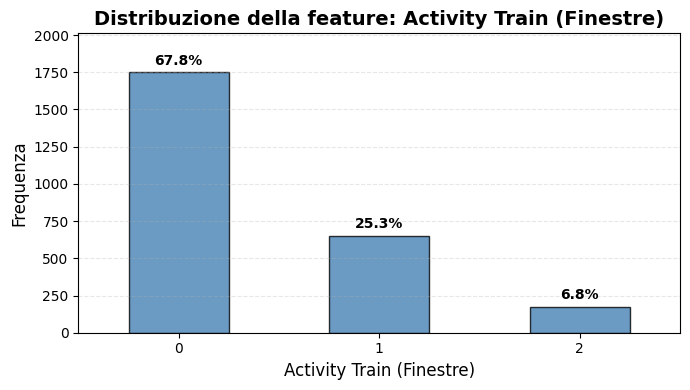

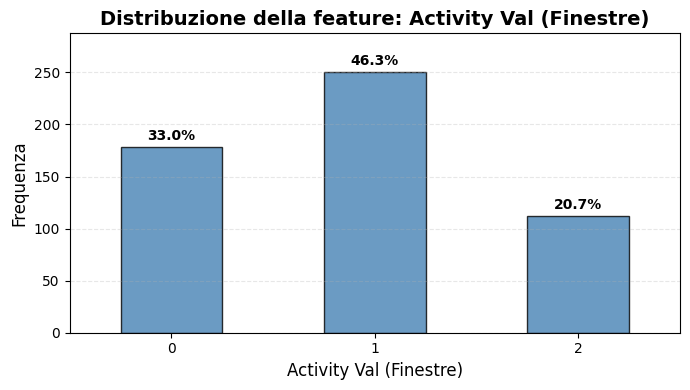

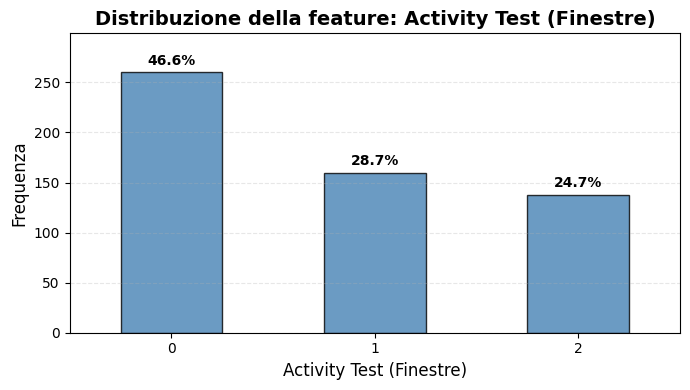

In [8]:
# Visualizzazione distribuzione classi
plot_feature_distribution(y_train, "Activity Train (Finestre)")
plot_feature_distribution(y_val, "Activity Val (Finestre)")
plot_feature_distribution(y_test, "Activity Test (Finestre)")

In [9]:
# CALCOLO CLASS WEIGHTS
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))

print("\nPESI DELLE CLASSI (per bilanciamento)")
for i, name in enumerate(CLASS_NAMES):
    print(f"Classe {i} ({name:8s}): peso = {class_weight_dict[i]:.3f}")


PESI DELLE CLASSI (per bilanciamento)
Classe 0 (Idle    ): peso = 0.491
Classe 1 (Walking ): peso = 1.316
Classe 2 (Cycling ): peso = 4.883


In [10]:
def build_model(input_shape, num_classes):
    """
    Architettura 1D-CNN
    """
    model = models.Sequential([
    # Unico blocco convolutivo robusto
      layers.Conv1D(filters=64, kernel_size=7, padding='same', input_shape=input_shape),
      layers.BatchNormalization(),
      layers.Activation('relu'),
      layers.MaxPooling1D(pool_size=4), # Riduzione drastica della dimensionalità

      # Global Average Pooling invece di Flatten o molti strati Dense
      layers.GlobalAveragePooling1D(),

      # Singolo strato di uscita con Dropout pesante
      layers.Dropout(0.55),
      layers.Dense(num_classes, activation='softmax')
  ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Costruzione modello
input_shape = (WINDOW_SIZE, len(FEATURES))
num_classes = 3
model = build_model(input_shape, num_classes)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 256, 64)        │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,547 (17.76 KB)

 Trainable params: 4,419 (17.26 KB)

 Non-trainable params: 128 (512.00 B)

In [11]:
# CALLBACKS
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

# TRAINING
print("\nINIZIO TRAINING")
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    class_weight=class_weight_dict,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


INIZIO TRAINING
Epoch 1/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.4795 - loss: 0.8762 - val_accuracy: 0.5815 - val_loss: 0.7920 - learning_rate: 0.0010
Epoch 2/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7550 - loss: 0.4734 - val_accuracy: 0.6685 - val_loss: 0.6395 - learning_rate: 0.0010
Epoch 3/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8058 - loss: 0.3822 - val_accuracy: 0.8278 - val_loss: 0.4754 - learning_rate: 0.0010
Epoch 4/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8437 - loss: 0.3402 - val_accuracy: 0.8963 - val_loss: 0.3641 - learning_rate: 0.0010
Epoch 5/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8508 - loss: 0.3186 - val_accuracy: 0.9204 - val_loss: 0.3112 - learning_rate: 0.0010
Epoch 6/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8642 - loss: 0.2975 - val_accuracy: 0.9296 - val_loss: 0.2721 - learning_rate: 0.0010
Epoch 7/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8788 - loss

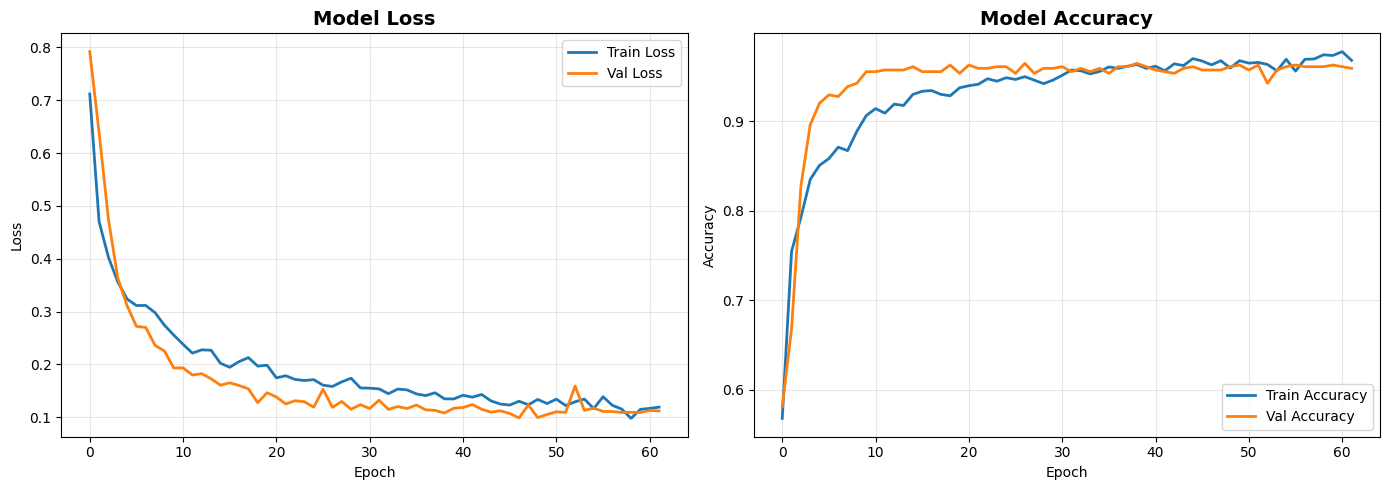

In [12]:
# PLOT DELLE CURVE DI TRAINING
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[1].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# VALUTAZIONE SUL TEST SET
print("\n" + "="*60)
print("VALUTAZIONE SUL TEST SET")
print("="*60)

# Predizioni
y_pred_proba = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

# Metriche generali
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
balanced_acc = balanced_accuracy_score(y_test, y_pred)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Balanced Accuracy: {balanced_acc:.4f} ({balanced_acc*100:.2f}%)")

# Classification Report
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4))


VALUTAZIONE SUL TEST SET

Test Loss: 0.1653
Test Accuracy: 0.9695 (96.95%)
Balanced Accuracy: 0.9706 (97.06%)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Idle     0.9843    0.9615    0.9728       260
     Walking     0.9353    0.9938    0.9636       160
     Cycling     0.9851    0.9565    0.9706       138

    accuracy                         0.9695       558
   macro avg     0.9682    0.9706    0.9690       558
weighted avg     0.9704    0.9695    0.9696       558



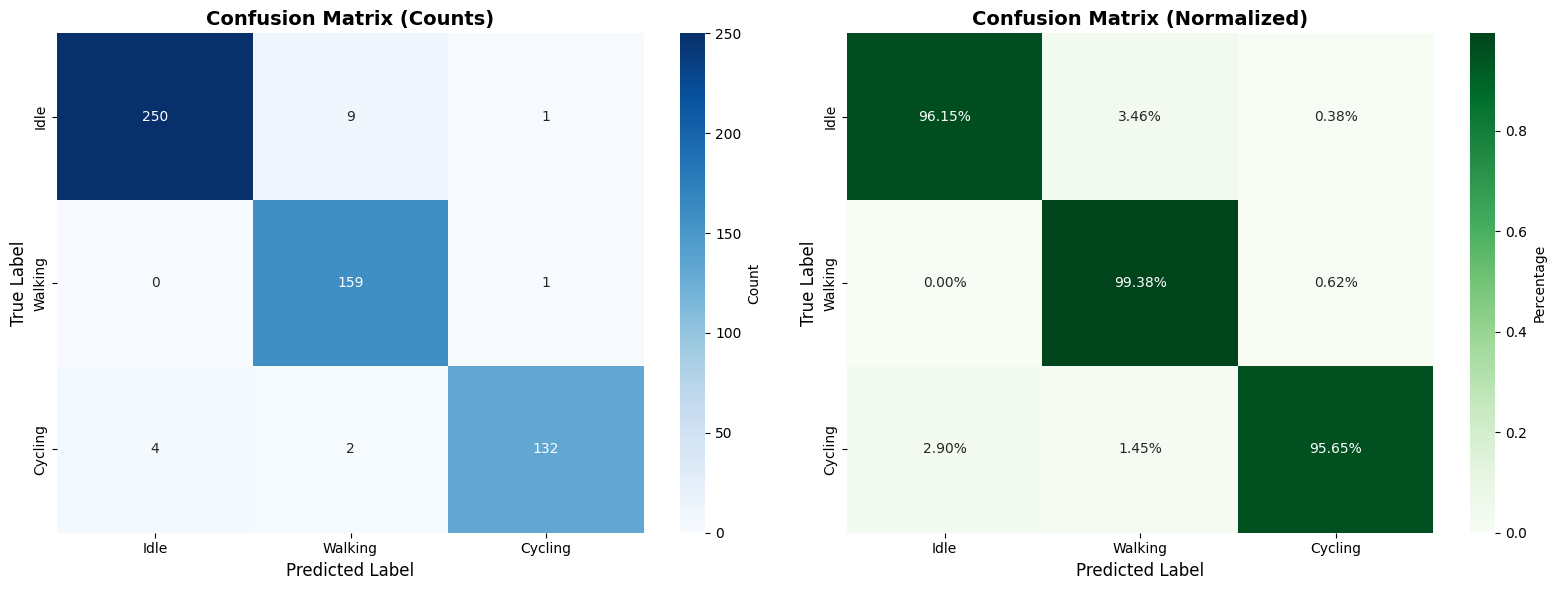

In [14]:
# MATRICE DI CONFUSIONE
cm = confusion_matrix(y_test, y_pred)

# Normalizzazione per percentuali
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matrice assoluta
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

# Matrice normalizzata
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1], cbar_kws={'label': 'Percentage'})
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.show()